# SSH wavenumber spectra (along track)

Compute SSH wavenumber spectra along SWOT track using SWOT LR L2 Basic products.

Step 1: Identify all segments of data that corresponds to ocean and select the ones that are longer than segment_length_km, as it does not make any physical sense to use segments that are shorter than segment length used to compute spectra.

Step 2 to 4 are run for each ocean segment defined in step 1. 

Step 2: Nadir gap between left and right swaths  is found and seperated datasets are created.

Step 3: For each side, function "along_track_spectrum" is applied to obtain spectra. To do so, overlapping segments are defined and spectra are computed for each of them. They are then averaged to obtain a mean spectra. The outputs of the function are: 1) wavenumber, kx ; 2) spectra averaged over all welch meothd segments and cross swath (num_pixels) ; 3) standard deviation on spectra across swath ; 4) individual spectra for each Welch method segments ; 5) mean latitude for each individual spectra

Step 4: Visualisation of wavenumber spectra depending on 



In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean as cm
from scipy.signal import welch, detrend, get_window
from scipy.signal import spectrogram
from scipy.ndimage import binary_dilation
from swot_analysis import plotting

In [2]:
#Loading individual granule file
data_dir = "/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/"
#data_dir = "/Users/zoecas/Documents/data/"
ds = xr.open_dataset(data_dir+"SWOT_L2_LR_SSH_Basic_044_348_20260115T192503_20260115T201545_PID0_01.nc")
ds

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-16T22:17:25Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.00961698815942
    ssha_variance:                                 0.8535355593218493
    references:                                    V1.4.1
    equator_longitude:                             8.21

(-10.0, 50.0)

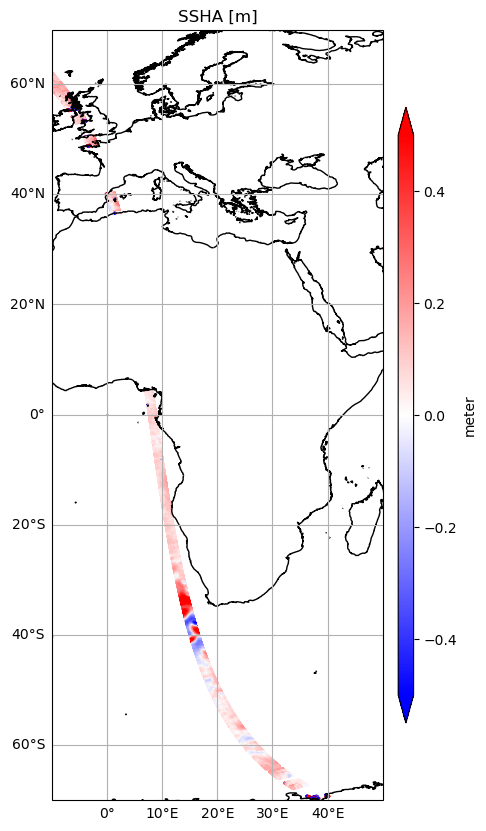

In [4]:
# Whole dataset
ssh_var = "ssha_karin"
title = 'SSHA [m]'
dat = (ds[ssh_var]+ds["height_cor_xover"]).where(np.isnan(ds[ssh_var])==False).values
lon = ds.longitude.where(np.isnan(dat)==False).values
lat = ds.latitude.where(np.isnan(dat)==False).values
vmin, vmax = -0.5,0.5

lonmax = ((ds.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((ds.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-10,50)

## Step 1 : Selecting ocean segments

In [5]:
def segment_swot_ocean_track(ds,water_var="ssh_karin",lat_var="latitude",track_dim="num_lines",pixel_dim="num_pixels",):
    """
    Segment a SWOT LR swath into continuous ocean segments. Save segment_id and mean_latitude for each segment.
    Parameters
    ----------
    ds : xr.Dataset
        SWOT LR L2 Basic dataset.
    water_var : str
        Variable used to identify ocean vs land.
        Typically ancillary_surface_classification_flag, etc.
    lat_var : str
        Latitude variable.
    track_dim : str
        Along-track dimension.
    pixel_dim : str
        Cross-track dimension.

    Returns
    -------
    ds_out : xr.Dataset
        Original dataset with:
            segment_id(track_dim)
            segment_mean_latitude(track_dim)

    segment_table : xr.Dataset
        Summary of ocean segments.
    """

    # ------------------------------------------------------------------
    # 1. Determine whether each line contains ocean data
    # ------------------------------------------------------------------

    ocean_line = (ds[water_var]==0).any(dim=pixel_dim)
    ocean_line = ocean_line.values.astype(bool)

    # ------------------------------------------------------------------
    # 2. Label contiguous ocean segments
    # ------------------------------------------------------------------

    segment_id = np.full(len(ocean_line), np.nan)
    seg = 0
    for i in range(len(ocean_line)):

        if ocean_line[i]:

            if i == 0 or not ocean_line[i - 1]:
                seg += 1
            segment_id[i] = seg

    # ------------------------------------------------------------------
    # 3. Representative latitude per line
    # ------------------------------------------------------------------

    lat_line = ds[lat_var].mean(dim=pixel_dim, skipna=True).values

    # ------------------------------------------------------------------
    # 4. Segment statistics
    # ------------------------------------------------------------------

    segment_mean_lat = np.full(len(segment_id), np.nan)

    seg_ids = []
    seg_mean_lat = []
    seg_start = []
    seg_end = []
    seg_nlines = []

    for sid in np.unique(segment_id[~np.isnan(segment_id)]):

        idx = segment_id == sid
        mean_lat = np.nanmean(lat_line[idx])
        segment_mean_lat[idx] = mean_lat

        seg_ids.append(int(sid))
        seg_mean_lat.append(mean_lat)
        seg_start.append(np.where(idx)[0][0])
        seg_end.append(np.where(idx)[0][-1])
        seg_nlines.append(idx.sum())

    # ------------------------------------------------------------------
    # 5. Attach to SWOT dataset
    # ------------------------------------------------------------------

    ds_out = ds.assign(segment_id=(track_dim, segment_id),segment_mean_latitude=(track_dim, segment_mean_lat),)

    # ------------------------------------------------------------------
    # 6. Segment summary table
    # ------------------------------------------------------------------

    segment_table = xr.Dataset({"mean_latitude": ("segment", seg_mean_lat),
                                "start_line": ("segment", seg_start),
                                "end_line": ("segment", seg_end),
                                "n_lines": ("segment", seg_nlines)},coords={"segment": seg_ids})

    return ds_out, segment_table

In [6]:
# Apply segment_swot_ocean_track 

ds_seg, seg_table = segment_swot_ocean_track(ds,water_var="ancillary_surface_classification_flag")
ds_seg

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/26)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
    segment_id                             (num_lines) float64 79kB 1.0 ... nan
    segment_mean_latitude                  (num_lines) float64 79kB 77.61 ......
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-16T22:17:25Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.00961698815942
    ssha_variance:                                 0.8535355593218493
    references:                                    V1.4.1
    equator_longitude:                             8.21

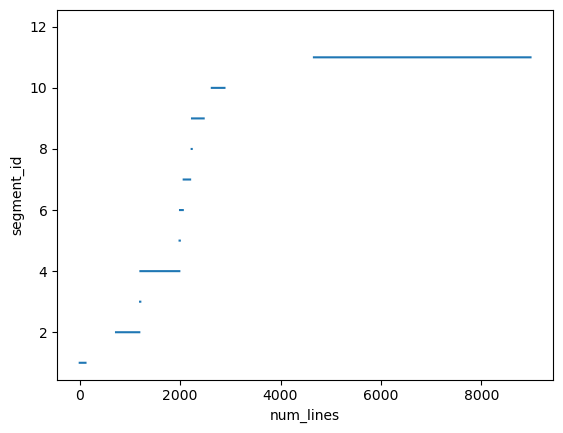

In [7]:
#Visualizing segments length
ds_seg.segment_id.plot()

In [8]:
# SWOT effective posting
DX_KM = 2.0

# Fu & Smith style averaging adapted for SWOT
SEGMENT_LENGTH_KM = 256.0

# minimum valid fraction for keeping a profile
MIN_VALID_FRAC = 0.90

In [9]:
# Remonving segments of continuous ocean smaller than segment size
ds_long =[]
for s in seg_table.segment:
    _ds = ds_seg.isel(num_lines=slice(seg_table.start_line[int(s)-1].values,seg_table.end_line[int(s)-1].values))

    #remove bad data using quality flags
    _ds = _ds.where(_ds[ssh_var+'_qual']==0)
    if _ds[ssh_var].shape[0]>=SEGMENT_LENGTH_KM/DX_KM and np.isfinite(_ds.ssh_karin).any()==True:
        ds_long.append(_ds)

## Intermediary step: Choosing ocean segment

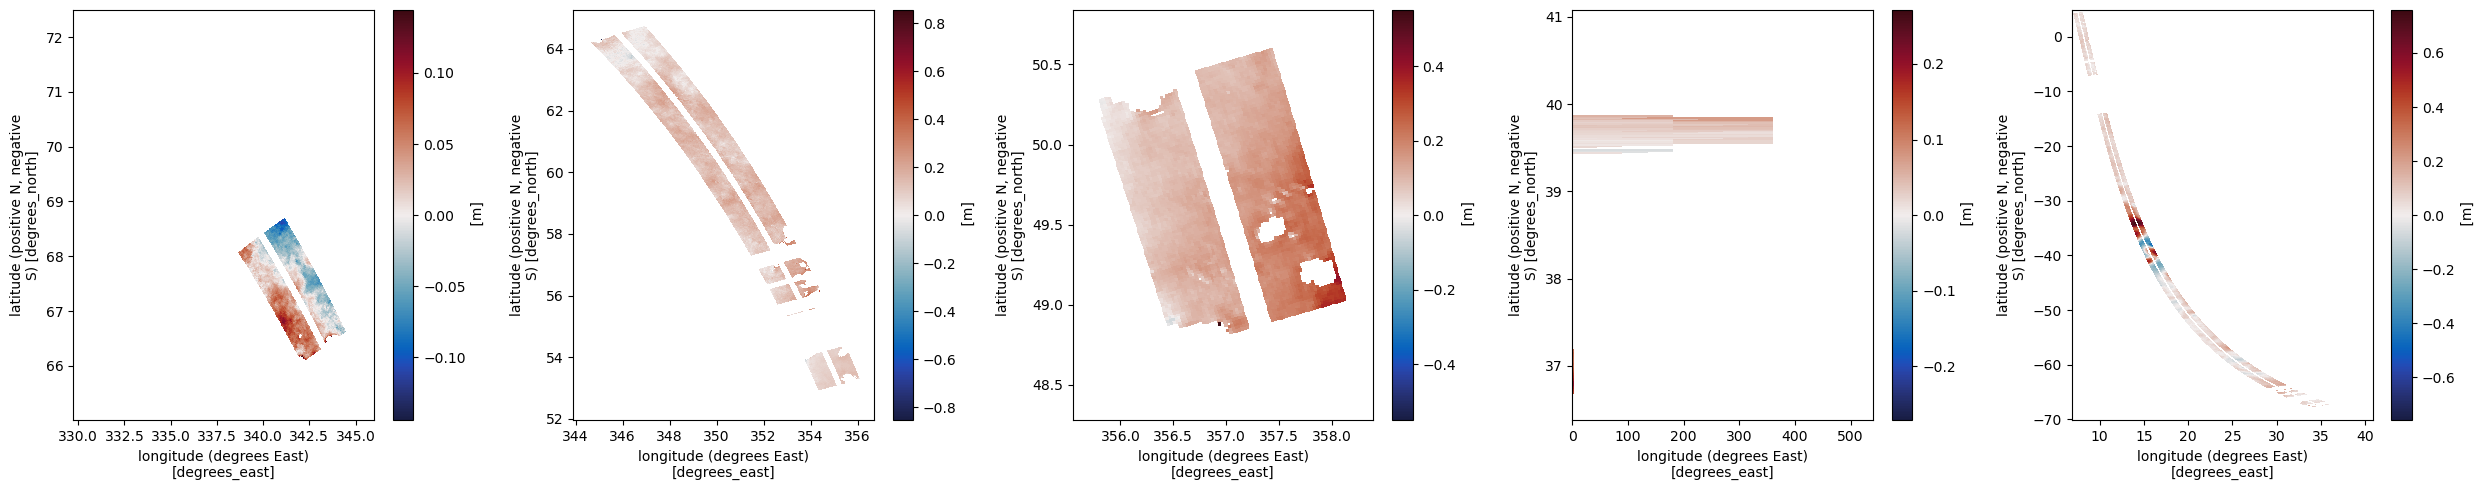

In [10]:
import cmocean
fig,axs=plt.subplots(1,len(ds_long),figsize=(5*len(ds_long),5))
for i in range(len(ds_long)):
    (ds_long[i][ssh_var]+ds_long[i]["height_cor_xover"]).plot(ax=axs[i],x='longitude',y='latitude',cmap=cmocean.cm.balance)
fig.tight_layout()

## Step 2: separating left and right swaths

In [11]:
def find_nadir_gap(ssh, min_valid_frac=0.2):
    """
    Find SWOT nadir gap indices robustly in the presence of land.

    Parameters
    ----------
    ssh : ndarray (n_along, n_cross)
        SWOT field with NaNs over land and in nadir gap.

    min_valid_frac : float
        Minimum fraction of valid samples required for a
        cross-track pixel to be considered part of a swath.

    Returns
    -------
    left_end : int
        Last cross-track index of left swath.

    right_start : int
        First cross-track index of right swath.

    gap_slice : slice
        Slice covering the nadir gap.

    valid_frac : ndarray
        Fraction of valid observations at each cross-track pixel.
    """

    # fraction of valid data at each cross-track position
    valid_frac = np.mean(np.isfinite(ssh), axis=0)
    # persistent swath mask
    swath_mask = valid_frac > min_valid_frac
    # contiguous valid regions
    edges = np.diff(np.r_[False, swath_mask, False].astype(np.int8))

    starts = np.flatnonzero(edges == 1)
    ends   = np.flatnonzero(edges == -1)

    if len(starts) < 2:
        raise ValueError(
            "Could not identify two SWOT swaths."
        )

    lengths = ends - starts

    # keep the two largest valid regions
    idx = np.argsort(lengths)[-2:]

    left_region, right_region = sorted(idx)

    left_end = ends[left_region] - 1
    right_start = starts[right_region]

    gap_slice = slice(left_end + 1, right_start)

    return left_end, right_start, gap_slice, valid_frac

In [12]:
i = -1 # ocean segment selection

lat = ds_long[i]['latitude']#.values
# Tilt correction
ssh = (ds_long[i][ssh_var]+ds_long[i]["height_cor_xover"])#.values

left_end, right_start, gap_slice, valid_frac = find_nadir_gap(ssh, min_valid_frac=0.2)

In [13]:
# Dealing with Nadir gap

ssh_left = ssh[:, :left_end]
ssh_right = ssh[:, right_start:]

lat_left = lat[:, :left_end]
lat_right = lat[:, right_start:]

print("Left swath:", ssh_left.shape)
print("Right swath:", ssh_right.shape)

Left swath: (4314, 30)
Right swath: (4314, 31)


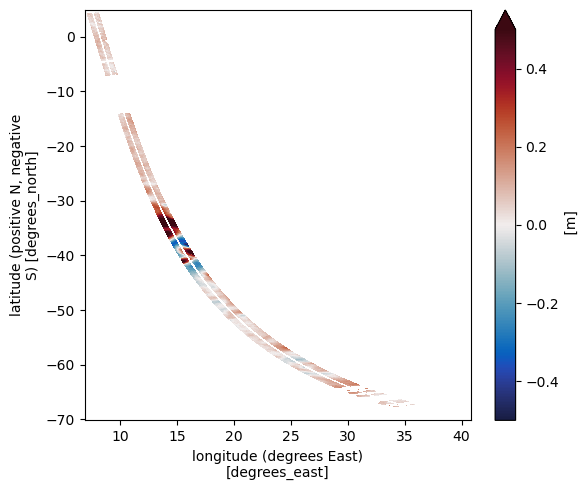

In [14]:
fig,ax=plt.subplots(figsize=(6,5))
(ds_long[i][ssh_var]+ds_long[i]["height_cor_xover"]).plot(ax=ax,x='longitude',y='latitude',cmap=cmocean.cm.balance,vmax=0.5)
fig.tight_layout()

## Step 3: Computing spectra

In [15]:
def fill_small_gaps(arr):
    da = xr.DataArray(arr,dims=["num_lines","num_pixels"])
    da = da.interpolate_na(dim="num_lines",method="linear")#,max_gap={'along':3})
    da = da.interpolate_na(dim="num_pixels",method="linear")#,max_gap={'along':3})
    return da.values

def along_track_spectrum(ssh_side, lat_side, dx=2.0, segment_length=256.0,return_segments=False):
    ssh_side = fill_small_gaps(ssh_side)
    lat_side = fill_small_gaps(lat_side)

    # Spectra parameters
    nperseg = int(segment_length / dx) #segment length
    noverlap = nperseg // 2 # overlap proportion
    step = nperseg - noverlap

    window = get_window("hann", nperseg)
    win_norm = np.sum(window**2)

    all_spectra = []   # store averaged segments results
    all_segment_spectra = []   # store per-segment results
    all_segment_lat = []   # store per-segment mean latitude
    kx_ref = None

    #Loop over all tracks in swath
    for j in range(ssh_side.shape[1]):
        profile = ssh_side[:, j]
        latitude = lat_side[:, j] 
        valid_frac = np.sum(np.isfinite(profile)) / len(profile)

        if valid_frac < MIN_VALID_FRAC:
            continue

        profile = np.where(np.isfinite(profile), profile, np.nanmean(profile))
        profile = detrend(profile, type="linear") #remove linear trend

        segment_spectra = []
        segment_lat = []
        
        # slide over segments explicitly
        for start in range(0, len(profile) - nperseg + 1, step):
            seg = profile[start:start + nperseg]

            seg = seg * window
            fft_seg = np.fft.rfft(seg)
            P = (np.abs(fft_seg) ** 2) / (win_norm * (1.0 / dx))

            kx = np.fft.rfftfreq(nperseg, d=dx)

            segment_spectra.append(P)
            segment_lat.append(np.mean(latitude[start:start+nperseg]))
        segment_spectra = np.asarray(segment_spectra)
        segment_lat = np.asarray(segment_lat)
        if kx_ref is None:
            kx_ref = kx

        # average over segments for this track
        P_mean = np.mean(segment_spectra, axis=0)

        all_spectra.append(P_mean)
        all_segment_spectra.append(segment_spectra)
        all_segment_lat.append(segment_lat)

    all_segment_spectra = np.asarray(all_segment_spectra)
    all_segment_lat = np.asarray(all_segment_lat)
    
    all_spectra = np.asarray(all_spectra)
    std_along = np.nanstd(all_spectra, axis=0)
    n_eff = np.sum(np.isfinite(all_spectra), axis=0)
    stderr_along = std_along / np.sqrt(n_eff)
    Ealong = np.nanmean(all_spectra, axis=0)

    if return_segments:
        return kx_ref, Ealong, stderr_along, all_segment_spectra, all_segment_lat
    else:
        return kx_ref, Ealong, stderr_along

In [16]:
#Left
kx_L, Ealong_L, stderr_L, all_seg_L,lat_L = along_track_spectrum(ssh_left,lat_left,dx=DX_KM,segment_length=SEGMENT_LENGTH_KM,return_segments=True)

#Right
kx_R, Ealong_R, stderr_R, all_seg_R,lat_R = along_track_spectrum(ssh_right,lat_right,dx=DX_KM,segment_length=SEGMENT_LENGTH_KM,return_segments=True)

In [17]:
# Adding both sides
E_along = (Ealong_L + Ealong_R)/2.0
stderr = np.sqrt(stderr_L**2 + stderr_R**2)/2.0
kx=kx_L #wavenumber [km-1]
wavelength = 1 / kx #Wavelength [km]

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_59244/1681193641.py:5: RuntimeWarning: divide by zero encountered in divide
  wavelength = 1 / kx #Wavelength [km]


## Step 4: Plots

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_59244/80340028.py:6: RuntimeWarning: divide by zero encountered in power
  ax.loglog(kx[:6],kx[:6]**(-5)/1e11,c='k')
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_59244/80340028.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,E_along[1]);ax.set_xlim(1/SEGMENT_LENGTH_KM,1/DX_KM);
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_59244/80340028.py:51: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,E_along[1]);ax.set_xlim(SEGMENT_LENGTH_KM,DX_KM);


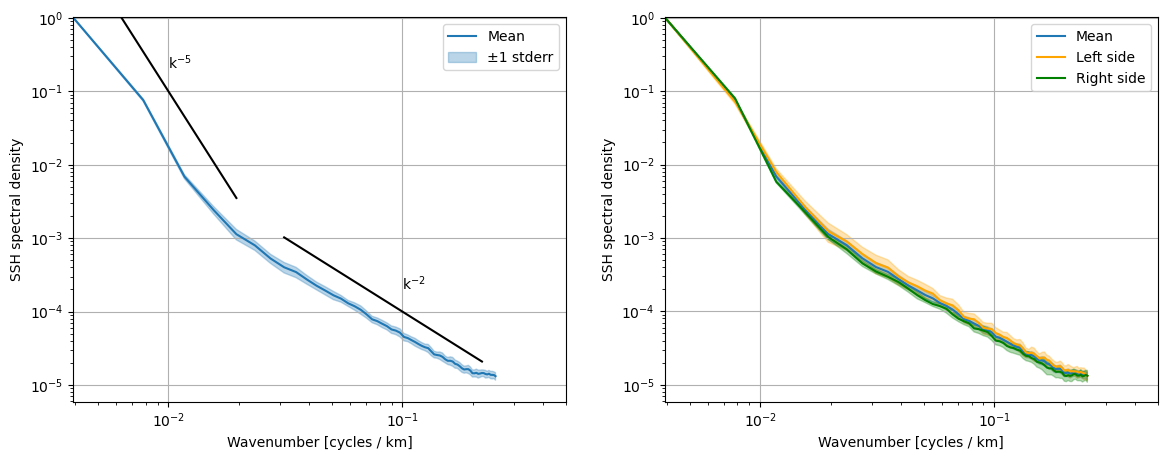

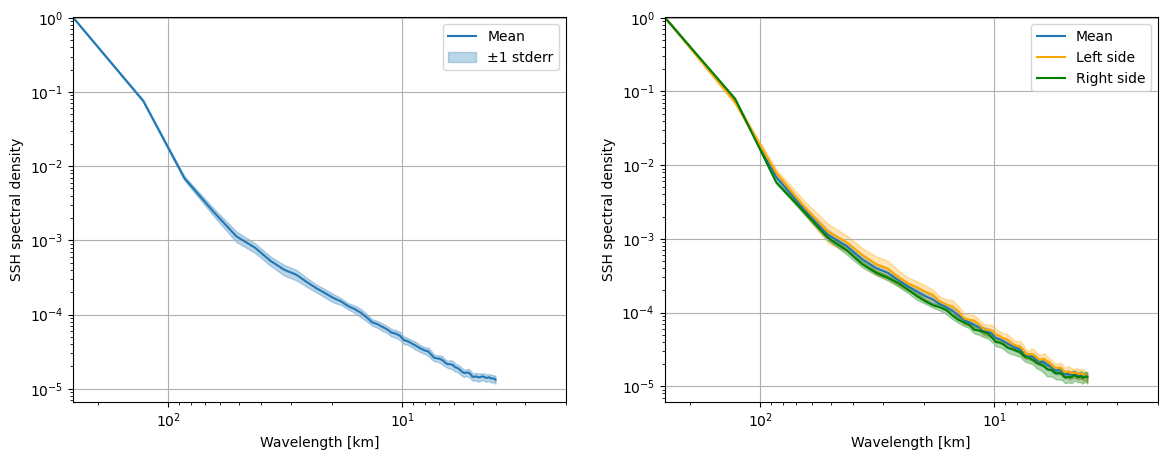

In [49]:
fig,axs = plt.subplots(1,2,figsize=(14,5))
ax=axs[0]
ax.loglog(kx[1:],E_along[1:],label="Mean")
ax.fill_between(kx,E_along - 1.96*stderr,E_along + 1.96*stderr,
                 color="C0",alpha=0.3,label="±1 stderr")
ax.loglog(kx[:6],kx[:6]**(-5)/1e11,c='k')
ax.loglog(kx[8:-8],kx[8:-8]**(-2)/1e6,c='k')
ax.text(0.01,0.2,r'k$^{-5}$');ax.text(0.1,0.0002,r'k$^{-2}$')

ax=axs[1]
ax.loglog(kx[1:],E_along[1:],label="Mean")
ax.fill_between(kx,E_along - 1.96*stderr,E_along + 1.96*stderr,
                 color="C0",alpha=0.3)

ax.loglog(kx[1:],Ealong_L[1:],label="Left side",c='orange')
ax.fill_between(kx,Ealong_L - 1.96*stderr_L,Ealong_L + 1.96*stderr_L,
                 color="orange",alpha=0.3)

ax.loglog(kx[1:],Ealong_R[1:],label="Right side", c= 'g')
ax.fill_between(kx,Ealong_R - 1.96*stderr_R,Ealong_R + 1.96*stderr_R,
                 color="g",alpha=0.3)



for ax in axs:
    ax.legend();ax.grid();
    ax.set_ylim(0,E_along[1]);ax.set_xlim(1/SEGMENT_LENGTH_KM,1/DX_KM);
    ax.set_xlabel('Wavenumber [cycles / km]');ax.set_ylabel('SSH spectral density');

fig,axs = plt.subplots(1,2,figsize=(14,5))
ax=axs[0]
ax.loglog(wavelength[1:],E_along[1:],label="Mean")
ax.fill_between(wavelength,E_along - 1.96*stderr,E_along + 1.96*stderr,
                 color="C0",alpha=0.3,label="±1 stderr")
ax=axs[1]
ax.loglog(wavelength[1:],E_along[1:],label="Mean")
ax.fill_between(wavelength,E_along - 1.96*stderr,E_along + 1.96*stderr,
                 color="C0",alpha=0.3)

ax.loglog(wavelength[1:],Ealong_L[1:],label="Left side",c='orange')
ax.fill_between(wavelength,Ealong_L - 1.96*stderr_L,Ealong_L + 1.96*stderr_L,
                 color="orange",alpha=0.3)

ax.loglog(wavelength[1:],Ealong_R[1:],label="Right side", c= 'g')
ax.fill_between(wavelength,Ealong_R - 1.96*stderr_R,Ealong_R + 1.96*stderr_R,
                 color="g",alpha=0.3)
#ax.loglog(ky[1:],E_cross[1:],label="Cross-track")
for ax in axs:
    ax.legend();ax.grid();
    ax.invert_xaxis()
    ax.set_ylim(0,E_along[1]);ax.set_xlim(SEGMENT_LENGTH_KM,DX_KM);
    ax.set_xlabel('Wavelength [km]');ax.set_ylabel('SSH spectral density');

## Dependence to latitude

In [50]:
mean_seg = (np.mean(all_seg_L,axis=0)+np.mean(all_seg_R,axis=0))/2.0
mean_lat = (np.mean(lat_L,axis=0)+np.mean(lat_R,axis=0))/2.0

(1e-06, np.float64(10.391121606121242))

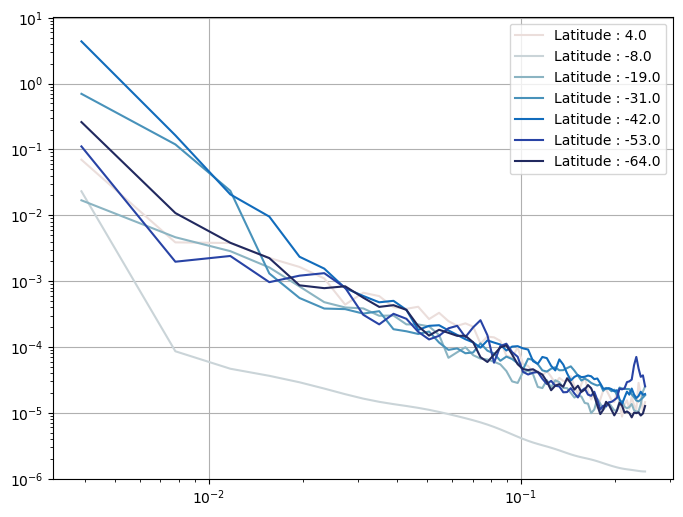

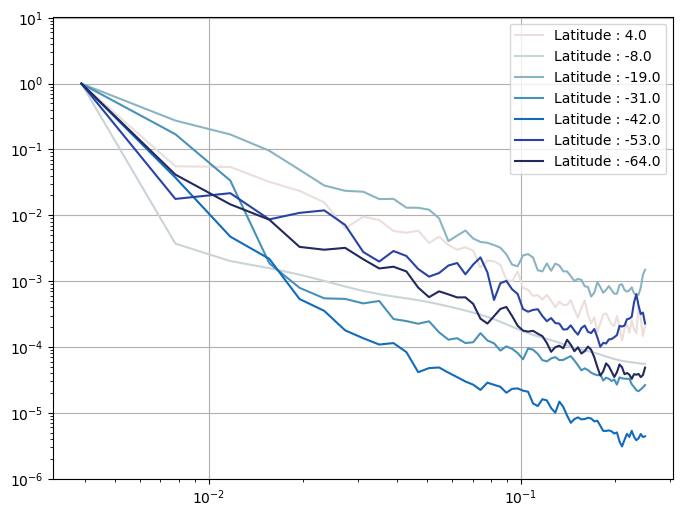

In [51]:
cmap_value = np.max([np.abs(np.min(mean_lat)),np.abs(np.max(mean_lat))])
c_norm = mpl.colors.Normalize(vmin=-cmap_value,vmax=cmap_value)

# Pick a colormap
c_map  = cm.cm.balance
#mpl.cm.coolwarm

# Scalar mappable of normalized array to colormap
s_map  = mpl.cm.ScalarMappable(cmap=c_map, norm=c_norm)
s_map.set_array([])
ni = 10
fig,ax = plt.subplots(figsize=(8,6))
for seg,color in zip(mean_seg[::ni,:],mean_lat[::ni]):
    ax.loglog(kx[1:],(seg[1:]),color=s_map.to_rgba(color),label=r'Latitude : %s'%np.around(color))

ax.legend(loc=1);ax.grid();
ax.set_ylim(1e-6,np.max(mean_seg[::ni,:]))

fig,ax = plt.subplots(figsize=(8,6))
for seg,color in zip(mean_seg[::ni,:],mean_lat[::ni]):
    ax.loglog(kx[1:],(seg[1:]/seg[1]),color=s_map.to_rgba(color),label=r'Latitude : %s'%np.around(color))

ax.legend(loc=1);ax.grid();
ax.set_ylim(1e-6,np.max(mean_seg[::ni,:]))